In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from western_us_biomass import dir_info
from western_us_biomass.make_figures import maps

In [2]:
inputs = xr.open_dataset(dir_info.dir_processed + "data_on_ref_grid/1000m/all_variables.nc")

In [3]:
def get_filtered_output(
    year,
    fdir=dir_info.dir_processed + "model_results/1000m_2026feb02_processed/",
    ftype="netcdf",
    vartype="predicted_biomass_filtered_",
):
    fname = fdir + vartype + str(year)
    if ftype == "zarr":
        ds = xr.open_zarr(fname + ".zarr")
    elif ftype == "netcdf":
        ds = xr.load_dataset(fname + ".nc")
    return ds


def clip_to_shape(da, shp):
    if shp.crs != da.rio.crs:
        shp = shp.to_crs(da.rio.crs)
    clipped = da.rio.clip(shp.geometry, shp.crs, drop=True)
    return clipped

In [4]:
# USFS data is not used in the figure but kept here for context
usfs = pd.read_csv("../figure_data/figure_2/USFS_western_stocks.csv")
usfs_deltas = usfs["0"].values[1:] - usfs["0"].values[:-1]
usfs_years = usfs["Unnamed: 0"].values[:-1]

In [5]:
slope = xr.open_zarr(dir_info.dir_processed + "data_on_ref_grid/1000m/aspect.zarr")
crs = slope["spatial_ref"].crs_wkt

In [6]:
years = np.arange(2005, 2023)

abs_carbon = []
for year in years:
    print(year)
    biomass_forest = get_filtered_output(year=year, vartype="predicted_biomass_filtered_")
    biomass_forest = biomass_forest.rio.write_crs(crs)
    biomass_forest_west = clip_to_shape(
        da=biomass_forest["predicted_biomass"], shp=maps.SHP_WESTERN
    )
    biomass_forest_west = biomass_forest_west.assign_coords(year=year)
    abs_carbon.append(biomass_forest_west)
    del biomass_forest

abs_carbon = xr.concat(abs_carbon, dim="year")

2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022


In [7]:
fire_losses_west = []
for year in years:
    print(year)
    biomass_forest = get_filtered_output(
        year=year, vartype="predicted_biomass_delta_burned_filtered_"
    )
    biomass_forest = biomass_forest.rio.write_crs(crs)
    biomass_forest_west = clip_to_shape(
        da=biomass_forest["predicted_biomass_delta_burned"], shp=maps.SHP_WESTERN
    )
    biomass_forest_west = biomass_forest_west.assign_coords(year=year)
    fire_losses_west.append(biomass_forest_west)
    del biomass_forest

fire_losses_west = xr.concat(fire_losses_west, dim="year")

2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022


In [8]:
unburned_gains_west = []
for year in years:
    print(year)
    biomass_forest = get_filtered_output(
        year=year, vartype="predicted_biomass_delta_unburned_filtered_"
    )
    biomass_forest = biomass_forest.rio.write_crs(crs)
    biomass_forest_west = clip_to_shape(
        da=biomass_forest["predicted_biomass_delta_unburned"], shp=maps.SHP_WESTERN
    )
    biomass_forest_west = biomass_forest_west.assign_coords(year=year)
    unburned_gains_west.append(biomass_forest_west)
    del biomass_forest

unburned_gains_west = xr.concat(unburned_gains_west, dim="year")

2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022


In [9]:
median_pct_loss = []
all_burned_pct_losses = []
years = np.arange(2005, 2022)
for year in years:
    fire_frac = inputs["FIRE_FRACTION"].sel(year=year)
    fire_mask = fire_frac > 0
    start_carbon = abs_carbon.sel(year=year)
    end_carbon = abs_carbon.sel(year=year + 1)
    delta_carbon = end_carbon - start_carbon
    delta_carbon_fire = fire_losses_west.sel(year=year)

    delta_carbon_fire_flat = delta_carbon_fire.where(fire_mask).values.flatten()
    delta_carbon_fire_flat_nonans = delta_carbon_fire_flat[~np.isnan(delta_carbon_fire_flat)]

    start_carbon_flat = (start_carbon * fire_frac).where(fire_mask).values.flatten()
    start_carbon_flat_nonans = start_carbon_flat[~np.isnan(delta_carbon_fire_flat)]

    delta_carbon_pct_fire_flat = delta_carbon_fire_flat_nonans * 100 / start_carbon_flat_nonans
    all_burned_pct_losses.append(delta_carbon_pct_fire_flat)
    year_median_loss = np.nanmedian(delta_carbon_pct_fire_flat)

    median_pct_loss.append(year_median_loss)

/tmp/ipykernel_688786/1479672745.py:18: RuntimeWarning: divide by zero encountered in divide
  delta_carbon_pct_fire_flat = delta_carbon_fire_flat_nonans * 100 / start_carbon_flat_nonans
/tmp/ipykernel_688786/1479672745.py:18: RuntimeWarning: divide by zero encountered in divide
  delta_carbon_pct_fire_flat = delta_carbon_fire_flat_nonans * 100 / start_carbon_flat_nonans
/tmp/ipykernel_688786/1479672745.py:18: RuntimeWarning: divide by zero encountered in divide
  delta_carbon_pct_fire_flat = delta_carbon_fire_flat_nonans * 100 / start_carbon_flat_nonans
/tmp/ipykernel_688786/1479672745.py:18: RuntimeWarning: divide by zero encountered in divide
  delta_carbon_pct_fire_flat = delta_carbon_fire_flat_nonans * 100 / start_carbon_flat_nonans
/tmp/ipykernel_688786/1479672745.py:18: RuntimeWarning: divide by zero encountered in divide
  delta_carbon_pct_fire_flat = delta_carbon_fire_flat_nonans * 100 / start_carbon_flat_nonans
/tmp/ipykernel_688786/1479672745.py:18: RuntimeWarning: divide by

In [10]:
all_burned_pct_losses_concat = np.concatenate(all_burned_pct_losses)
all_burned_pct_losses_nonans = all_burned_pct_losses_concat[~np.isinf(all_burned_pct_losses_concat)]

In [11]:
from conus_biomass.train_models import train_all_models

fia_data = train_all_models.load_data()
fia_data_west = fia_data.where(
    fia_data["STATECD"].isin([4, 6, 8, 16, 30, 32, 35, 41, 49, 53, 56]).load(),
    drop=True,
)

fia_data_burned = fia_data_west.where(
    (fia_data_west["fire_between_measurements"] > 0).load(), drop=True
)

fia_deltas = (
    fia_data_burned["biomass_delta"]
    * 100
    / fia_data_burned["biomass"].sel(year=fia_data_burned["measyear_1"])
)

/home/jovyan/.local/lib/python3.10/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/jovyan/.local/lib/python3.10/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/jovyan/.local/lib/python3.10/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/jovyan/.local/lib/python3.10/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/jovyan/.local/lib/python3.10/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/jovyan/.local/lib/python3.10/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/jovyan/.local/lib/python3.10/site-packages/

In [12]:
fires = fia_data_burned["fires_occurred"]
measyear2 = fia_data_burned["measyear_2"]
measyear1 = fia_data_burned["measyear_1"]

valid = fires.where((fires > 0) & (fires.year < measyear2) & (fires.year > measyear1))

last_fire_year = valid.year.where(valid > 0).max(dim="year").compute()

fia_deltas_clean = fia_deltas.where(np.isfinite(fia_deltas))

In [13]:
vals = fia_deltas_clean.compute().groupby(last_fire_year).mean()
counts = fia_deltas_clean.compute().groupby(last_fire_year).count()
std = fia_deltas_clean.compute().groupby(last_fire_year).std()

se = std / np.sqrt(counts)

In [14]:
vals = vals.where(counts > 20)

In [15]:
# ── Save all data needed by the figure notebook ─────────────────────────────
save_dir = "../figure_data/figure_S_tree_mortality/"
os.makedirs(save_dir, exist_ok=True)

# 1. years array (2005-2021) used in the time-series subplot
np.save(os.path.join(save_dir, "years.npy"), years)

# 2. per-year model median loss
np.save(os.path.join(save_dir, "median_pct_loss.npy"), np.array(median_pct_loss))

# 3. all pixel-level model losses (infs removed) – histogram & overall mean
np.save(os.path.join(save_dir, "all_burned_pct_losses_nonans.npy"), all_burned_pct_losses_nonans)

# 4. FIA per-year mean (xarray DataArray) – time-series subplot
vals.to_netcdf(os.path.join(save_dir, "vals.nc"))

# 5. Scalar mean of fia_deltas_clean – FIA reference line
fia_deltas_clean_mean = float(np.mean(fia_deltas_clean).compute())
np.save(os.path.join(save_dir, "fia_deltas_clean_mean.npy"), np.array([fia_deltas_clean_mean]))

# 6. FIA deltas with infs removed – histogram
fia_deltas_finite = fia_deltas[~np.isinf(fia_deltas).load()].values.flatten()
np.save(os.path.join(save_dir, "fia_deltas_finite.npy"), fia_deltas_finite)

print(f"Data saved to '{save_dir}/'")

Data saved to '../figure_data/figure_S_tree_mortality//'


(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  48., 820.,  73.,
         69.,  58.,  62.,  74.,  57.,  73.,  67.,  60.,  53.,  65.,  69.,
         76.,  82.,  74.,  82.,  81.,  84., 105.,  98., 101.,  78.,  67.,
         45.,  37.,  23.,  20.,  14.,  16.,   9.,  10.,   6.,   3.,   5.,
          1.,   6.,   4.,   3.,   5.,   4.,   2.,   2.,   1.,   0.,   1.,
          3.,   2.,   2.,   0.,   0.,   2.,   0.,   0.,   1.,   0.,   0.,
          0.,   0.]),
 array([-200., -195., -190., -185., -180., -175., -170., -165., -160.,
        -155., -150., -145., -140., -135., -130., -125., -120., -115.,
        -110., -105., -100.,  -95.,  -90.,  -85.,  -80.,  -75.,  -70.,
         -65.,  -60.,  -55.,  -50.,  -45.,  -40.,  -35.,  -30.,  -25.,
         -20.,  -15.,  -10.,   -5.,    0.,    5.,   10.,   15.,   20.,
          25.,   30.,   35.,   40.,   45.,   50.,   55.,   60.,   65.,
          70.,   75.,   80.,   85.

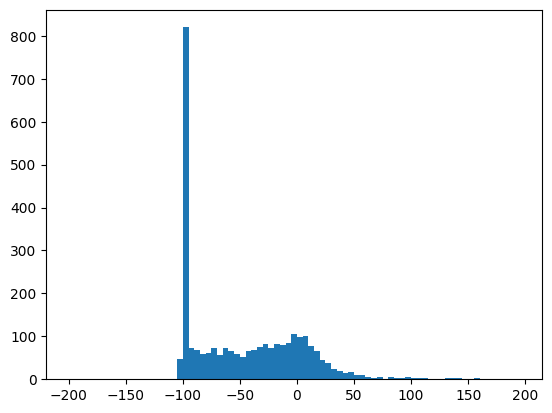

In [22]:
plt.hist(fia_deltas_clean, bins=np.arange(-200, 200, 5))

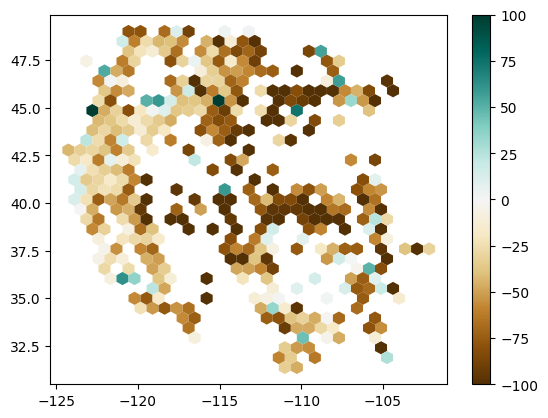

In [30]:
plt.hexbin(
    x=fia_data_burned["lon"],
    y=fia_data_burned["lat"],
    C=fia_deltas_clean,
    vmax=100,
    vmin=-100,
    cmap=plt.cm.BrBG,
    gridsize=30,
    edgecolor="none",
)
plt.colorbar()